## Import libs

In [1]:
from sklearn.model_selection import train_test_split
import seaborn as sns

from tensorflow.keras.optimizers import Adam
from tensorflow.data import Dataset

from falsb4mpa.dataset.load_data import load_data
from falsb4mpa.evaluation.evaluation import compute_predictive_metrics, compute_fair_metrics, compute_tradeoff, compute_intersectional_fair_metrics
from falsb4mpa.modeling.vanilla_lr.model import VanillaLogisticRegression
from falsb4mpa.modeling.vanilla_lr.learning import train_loop

from falsb4mpa.evaluation.evaluation import evaluation

## Preliminaries

In [2]:
batch_size = 64
epochs = 10
learning_rate = 0.001
opt = Adam(learning_rate=learning_rate)

In [3]:
cv_seeds = [13]
# cv_seeds = [13, 29, 42, 55, 73]

## Load data

In [4]:
data_name = 'adult-mpa-bin-wout-agg'

In [5]:
x, y, a1, a2 = load_data(data_name)
raw_data = (x, y, a1, a2)

In [6]:
xdim = x.shape[1]
ydim = y.shape[1]
a1dim = a1.shape[1]
a2dim = a2.shape[1]
zdim = 8
print(xdim, ydim, a1dim, a2dim, zdim)

97 1 1 1 8


## Result file

In [7]:
header = "model_name", "cv_seed", "clas_acc", "a1_dp", "a1_deqodds", "a1_deqopp", "a1_TN_g0", "a1_FP_g0", "a1_FN_g0", "a1_TP_g0", "a1_TN_g1", "a1_FP_g1", "a1_FN_g1", "a1_TP_g1", "a0_dp", "a0_deqodds", "a0_deqopp", "a0_TN_g0", "a0_FP_g0", "a0_FN_g0", "a0_TP_g0", "a0_TN_g1", "a0_FP_g1", "a0_FN_g1", "a0_TP_g1"

results = []

## Testing

In [9]:
results= []
for cv_seed in cv_seeds:
        x_train, x_test, y_train, y_test, a1_train, a1_test, a2_train, a2_test = train_test_split(
                x, y, a1, a2, test_size=0.3, random_state=cv_seed
        )
        
        train_data = Dataset.from_tensor_slices((x_train, y_train, a1_train, a2_train))
        train_data = train_data.batch(batch_size, drop_remainder=True)

        test_data = Dataset.from_tensor_slices((x_test, y_test, a1_test, a2_test))
        test_data = test_data.batch(batch_size, drop_remainder=True)
        
        model = VanillaLogisticRegression(xdim, ydim, batch_size)
        ret = train_loop(model, train_data, epochs)
        
        Y, A1, A2, Y_hat = evaluation(model, test_data)

        clas_acc, clas_f1_micro, clas_f1_macro, confusion_matrix = compute_predictive_metrics(Y, Y_hat)
        
        a1_dp, a1_deqodds, a1_deqopp, a1_metrics_g0, a1_metrics_g1 = compute_fair_metrics(Y, A1, Y_hat, a1dim)
        a2_dp, a2_deqodds, a2_deqopp, a2_metrics_g0, a2_metrics_g1 = compute_fair_metrics(Y, A2, Y_hat, a2dim)

        wc_spd, wc_aod, wc_eod = compute_intersectional_fair_metrics(Y, A1, A2, Y_hat, a1dim, a2dim)
        
        # fair_metrics = (dp, deqodds, deqopp)
        
        # tradeoff = []
        
        # for fair_metric in fair_metrics:
        #         tradeoff.append(compute_tradeoff(clas_acc, fair_metric))
        
        # result = ['UnfairLR-decay', cv_seed, clas_acc, dp, deqodds, deqopp, tradeoff[0], tradeoff[1], tradeoff[2]]

        result = ['VanillaLR', cv_seed, clas_acc, a1_dp, a1_deqodds, a1_deqopp] + a1_metrics_g0 + a1_metrics_g1 
        result += [a2_dp, a2_deqodds, a2_deqopp] + a2_metrics_g0 + a2_metrics_g1
        result += [wc_spd, wc_aod, wc_eod]

        results.append(result)
        

> Epoch | Class Loss | Class Acc
> 1 | 0.47688028216362 | 0.6151632085020243
> 2 | 0.4122905433177948 | 0.7887778340080972
> 3 | 0.39054590463638306 | 0.8121204453441295


2026-05-04 14:28:30.919792: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


> 4 | 0.3794165849685669 | 0.8185096153846154
> 5 | 0.37254878878593445 | 0.8224316801619433
> 6 | 0.36782532930374146 | 0.8233805668016194
> 7 | 0.364335298538208 | 0.8249620445344129
> 8 | 0.36162322759628296 | 0.8257844129554656
> 9 | 0.35943603515625 | 0.8265118927125507
> 10 | 0.35762178897857666 | 0.8270812246963563
> Predictive Performance Evaluation
> Class Acc = 0.8287914395332336
> Confusion Matrix 
TN: 9509.0 | FP: 649.0 
FN: 1663.0 | TP: 1683.0
> Fairness Evaluation
> DP | DEqOdds | DEqOpp
> 0.8275365829467773 | 0.8817393779754639 | 0.8428789377212524
> Confusion Matrix for A = 0 
TN: 5697.0 | FP: 592.0 
FN: 1341.0 | TP: 1494.0
> Confusion Matrix for A = 1 
TN: 3812.0 | FP: 57.0 
FN: 322.0 | TP: 189.0
> Fairness Evaluation
> DP | DEqOdds | DEqOpp
> 0.9618479013442993 | 0.9608250856399536 | 0.926849901676178
> Confusion Matrix for A = 0 
TN: 7992.0 | FP: 553.0 
FN: 1533.0 | TP: 1511.0
> Confusion Matrix for A = 1 
TN: 1517.0 | FP: 96.0 
FN: 130.0 | TP: 172.0
> Intersectional

In [10]:
print(clas_acc, clas_f1_micro, clas_f1_macro)

0.82879144 0.8287914691943128 0.7422112175087238


<Axes: >

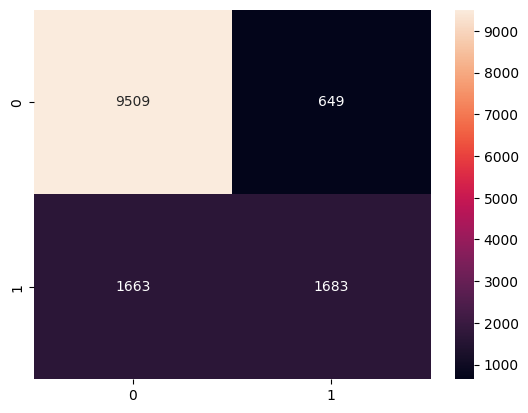

In [11]:
sns.heatmap(confusion_matrix, annot=True, fmt='g')

## Saving into DF then CSV

In [ ]:
# result_df = pd.DataFrame(results, columns=header)
# result_df

In [ ]:
# result_df.to_csv(f'{data_name}-result/unfair_lr-{epochs}.csv')